In [1]:
%%capture

!pip install pandas matplotlib numpy

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = "https://api.open-meteo.com/v1/forecast"

In [ ]:
latitude = -16.40
longitude = -49.15

In [ ]:
params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": ["temperature_2m", "relative_humidity_2m"],
        "timezone": "auto",
}

In [ ]:
response = requests.get(url, params= params)

In [ ]:
data = response.json()

In [ ]:
df = pd.DataFrame({"datetime": data['hourly']['time'],
                   "temperatura": data['hourly']['temperature_2m'],
                  "humidade_relativa": data['hourly']['relative_humidity_2m']})

In [ ]:
# df['datetime'] = pd.to_datetime(df['datetime'], format= '%Y-%m-%dT H:M:S')

ValueError: time data "2026-08-28T00:00" doesn't match format "%Y-%m-%dT H:M:S", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
df['datetime_data'] = df['datetime'].dt.date

In [ ]:
df['datetime_data']

,datetime_data
0,2026-08-28
1,2026-08-28
2,2026-08-28
3,2026-08-28
4,2026-08-28
...,...
163,2026-09-03
164,2026-09-03
165,2026-09-03
166,2026-09-03


# Qual a missão?
# Um dashboard inteligente que mostra a temperatura/humidade relativa média das cinco cidades mais importantes do país além da temperatura média
# esperada.

In [ ]:
# O que eu quero desconbrir a temperatura média máxima do dia?

#AGEMC
- Ask        -  A pergunta
- Get        -  A obtenção dos dados
- Explorer   -  Exploração dos dados
- Model      -  O desenvolvemento de um modelo
- Comunicate -  A comunicação dos dados


#A Missão do Ciêntista de Dados
- Extrair Conhecimento de Dados Desorganizados

#

# 5W2h

- Oque ?
- Porquê ?
- Quando ?
- Como ?
- Onde ?
- Quem ?
- Quanto custa ?

In [ ]:
df.head()

,datetime,temperatura,humidade_relativa,datetime_data
0,2026-08-28 00:00:00,25.0,47,2026-08-28
1,2026-08-28 01:00:00,24.9,48,2026-08-28
2,2026-08-28 02:00:00,24.3,50,2026-08-28
3,2026-08-28 03:00:00,22.9,55,2026-08-28
4,2026-08-28 04:00:00,22.4,57,2026-08-28


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   datetime           168 non-null    datetime64[ns]
 1   temperatura        168 non-null    float64       
 2   humidade_relativa  168 non-null    int64         
 3   datetime_data      168 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 5.4+ KB


In [ ]:
df.describe()

,datetime,temperatura,humidade_relativa
count,168,168.000000,168.000000
mean,2026-08-31 11:30:00.000000256,27.695833,42.642857
min,2026-08-28 00:00:00,20.300000,17.000000
25%,2026-08-29 17:45:00,23.600000,25.000000
50%,2026-08-31 11:30:00,26.800000,35.000000
75%,2026-09-02 05:15:00,32.350000,53.500000
max,2026-09-03 23:00:00,36.300000,97.000000
std,NaN,4.723687,22.278124


In [ ]:
df['dia_semana'] = df['datetime'].dt.day_name()

In [ ]:
relatorio_clima = df.groupby('datetime_data').agg({
    "temperatura": ["min", "max", "mean"],
    "humidade_relativa": ["min", "max", "mean"]
}).reset_index()

In [ ]:
relatorio_clima.to_json()

'{"(\'datetime_data\', \'\')":{"0":1787875200000,"1":1787961600000,"2":1788048000000,"3":1788134400000,"4":1788220800000,"5":1788307200000,"6":1788393600000},"(\'temperatura\', \'min\')":{"0":22.0,"1":21.1,"2":23.2,"3":24.1,"4":22.6,"5":20.4,"6":20.3},"(\'temperatura\', \'max\')":{"0":34.0,"1":34.8,"2":35.6,"3":36.3,"4":35.6,"5":33.5,"6":27.7},"(\'temperatura\', \'mean\')":{"0":27.775,"1":28.2666666667,"2":29.1708333333,"3":29.925,"4":28.9041666667,"5":26.0958333333,"6":23.7333333333},"(\'humidade_relativa\', \'min\')":{"0":22,"1":20,"2":19,"3":17,"4":18,"5":32,"6":53},"(\'humidade_relativa\', \'max\')":{"0":58,"1":52,"2":39,"3":39,"4":57,"5":97,"6":92},"(\'humidade_relativa\', \'mean\')":{"0":38.9166666667,"1":34.375,"2":28.8333333333,"3":26.1666666667,"4":30.0,"5":61.9583333333,"6":78.25}}'

In [ ]:
relatorio_clima['temperatura']['max'] # Dicionário de dicionários, acessamo um dicionário e um dicionário no interior de outros

,max
0,34.0
1,34.8
2,35.6
3,36.3
4,35.6
5,33.5
6,27.7


In [ ]:
clima_amanha = relatorio_clima.loc[1].copy()

In [ ]:
clima_amanha['temperatura']

,1
min,21.1
max,34.8
mean,28.266667


In [ ]:
clima_amanha["datetime_data"]

,1
,2026-08-29


In [ ]:
# Uma função que retorna o clima e a temperatura de amanhã

In [ ]:
params = {"latitude": latitude,
"longitude": longitude,
"hourly": ["temperature_2m", "relative_humidity_2m"],
"timezone": "auto",}

In [13]:
def obter_clima(nome_cidade: str, nome_estado: str, latitude: float, longitude: float):

    """
        Uma função que retorna o clima temperatura e humidade (máxima e mínima)
        esperadas para o próximo dia.
    """

    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": ["temperature_2m", "relative_humidity_2m"],
        "timezone": "auto"
    }

    response = requests.get(url, params)
    # print("resposta_obtida")

    # print(response)

    # Transformando a definição em um json.
    data = response.json()

    # print("Data obtida")

    # Criando um DataFrame
    df = pd.DataFrame({
        "data": pd.to_datetime(data['hourly']['time']),
        "temperatura": data['hourly']['temperature_2m'],
        "humidade_relativa": data['hourly']['relative_humidity_2m']
    })


    # Uma coluna apenas com a data dia/mês/ano
    df['data_dia'] = df['data'].dt.date

    previsao_climatica = df.groupby('data_dia').agg({
        "temperatura": ["min", "max", "mean"],
        "humidade_relativa": ["min", "max", "mean"]
    }).reset_index()


    previsao_amanha = previsao_climatica.loc[1].copy()

    # print(previsao_amanha)

    dia = previsao_amanha['data_dia']
    temp = previsao_amanha['temperatura']
    humid = previsao_amanha['humidade_relativa']

    return {
        "cidade": nome_cidade,
        "estado": nome_estado,
        "dia": dia,
        "temperatura": {"min": temp['min'], "max": temp["max"], "mean": temp["mean"]},
        "humidade": {"min": humid['min'], "max": humid['max'], "mean": humid["mean"]}
    }

In [ ]:
df = pd.DataFrame({"datetime": data['hourly']['time'],
                   "temperatura": data['hourly']['temperature_2m'],
                  "humidade_relativa": data['hourly']['relative_humidity_2m']})

In [ ]:
print(url)

https://api.open-meteo.com/v1/forecast


In [ ]:
latitude = -16.40
longitude = -49.15

In [ ]:
clima_goiania = clima(-16.40, -49.15)

In [ ]:
clima_goiania

{'dia':     2026-08-29
 Name: 1, dtype: object,
 'temperatura': {'min': np.float64(21.1),
  'max': np.float64(34.8),
  'mean': np.float64(28.266666666666666)},
 'humidade': {'min': np.int64(20),
  'max': np.int64(52),
  'mean': np.float64(34.375)}}

In [4]:
cidades_importantes = [
    # São Paulo
    {
        "nome_cidade": "São Paulo",
        "nome_estado": "São Paulo",
        "latitude_longitude": (-23.5505, -46.6333)
    },
    {
        "nome_cidade": "Campinas",
        "nome_estado": "São Paulo",
        "latitude_longitude": (-22.9099, -47.0626)
    },
    {
        "nome_cidade": "Guarulhos",
        "nome_estado": "São Paulo",
        "latitude_longitude": (-23.4628, -46.5333)
    },

    # Rio de Janeiro
    {
        "nome_cidade": "Rio de Janeiro",
        "nome_estado": "Rio de Janeiro",
        "latitude_longitude": (-22.9068, -43.1729)
    },
    {
        "nome_cidade": "Niterói",
        "nome_estado": "Rio de Janeiro",
        "latitude_longitude": (-22.8833, -43.1036)
    },
    {
        "nome_cidade": "Duque de Caxias",
        "nome_estado": "Rio de Janeiro",
        "latitude_longitude": (-22.7856, -43.3117)
    },

    # Minas Gerais
    {
        "nome_cidade": "Belo Horizonte",
        "nome_estado": "Minas Gerais",
        "latitude_longitude": (-19.9208, -43.9378)
    },
    {
        "nome_cidade": "Uberlândia",
        "nome_estado": "Minas Gerais",
        "latitude_longitude": (-18.9186, -48.2772)
    },
    {
        "nome_cidade": "Juiz de Fora",
        "nome_estado": "Minas Gerais",
        "latitude_longitude": (-21.7642, -43.3496)
    },

    # Goiás
    {
        "nome_cidade": "Goiânia",
        "nome_estado": "Goiás",
        "latitude_longitude": (-16.6869, -49.2648)
    },
    {
        "nome_cidade": "Aparecida de Goiânia",
        "nome_estado": "Goiás",
        "latitude_longitude": (-16.8250, -49.2458)
    },
    {
        "nome_cidade": "Anápolis",
        "nome_estado": "Goiás",
        "latitude_longitude": (-16.3267, -48.9528)
    },

    # Santa Catarina
    {
        "nome_cidade": "Joinville",
        "nome_estado": "Santa Catarina",
        "latitude_longitude": (-26.3044, -48.8456)
    },
    {
        "nome_cidade": "Florianópolis",
        "nome_estado": "Santa Catarina",
        "latitude_longitude": (-27.5954, -48.5480)
    },
    {
        "nome_cidade": "Blumenau",
        "nome_estado": "Santa Catarina",
        "latitude_longitude": (-26.9194, -49.0661)
    }
]

In [7]:
obter_clima()

TypeError: obter_clima() missing 4 required positional arguments: 'cidade', 'estado', 'latitude', and 'longitude'

In [18]:
def obter_dados_climaticos():

    resultados = [
                obter_clima(
                            nome_cidade= dicionario_cidade['nome_cidade'],
                            nome_estado= dicionario_cidade['nome_estado'],
                            latitude= dicionario_cidade['latitude_longitude'][0],
                            longitude= dicionario_cidade['latitude_longitude'][1]
                            ) for dicionario_cidade in cidades_importantes

                ]


    return resultados

In [21]:
def main():

    resultados_climaticos = obter_dados_climaticos()

    print(resultados_climaticos[0])

In [23]:
resultados_climaticos = obter_dados_climaticos()

In [37]:
resultados_climaticos[0]

{'cidade': 'São Paulo',
 'estado': 'São Paulo',
 'dia':     2026-08-30
 Name: 1, dtype: object,
 'temperatura': {'min': np.float64(20.3),
  'max': np.float64(30.9),
  'mean': np.float64(24.34166666666667)},
 'humidade': {'min': np.int64(38),
  'max': np.int64(91),
  'mean': np.float64(68.08333333333333)}}

In [39]:
resultados_climaticos[3]

{'cidade': 'Rio de Janeiro',
 'estado': 'Rio de Janeiro',
 'dia':     2026-08-30
 Name: 1, dtype: object,
 'temperatura': {'min': np.float64(21.7),
  'max': np.float64(26.8),
  'mean': np.float64(24.070833333333336)},
 'humidade': {'min': np.int64(76),
  'max': np.int64(98),
  'mean': np.float64(87.54166666666667)}}

In [32]:
resultados_climaticos[6]

{'cidade': 'Belo Horizonte',
 'estado': 'Minas Gerais',
 'dia':     2026-08-30
 Name: 1, dtype: object,
 'temperatura': {'min': np.float64(19.8),
  'max': np.float64(30.9),
  'mean': np.float64(24.754166666666666)},
 'humidade': {'min': np.int64(36),
  'max': np.int64(78),
  'mean': np.float64(61.625)}}

In [33]:
resultados_climaticos[9]

{'cidade': 'Goiânia',
 'estado': 'Goiás',
 'dia':     2026-08-30
 Name: 1, dtype: object,
 'temperatura': {'min': np.float64(25.8),
  'max': np.float64(35.8),
  'mean': np.float64(31.133333333333336)},
 'humidade': {'min': np.int64(18),
  'max': np.int64(41),
  'mean': np.float64(27.666666666666668)}}

In [34]:
resultados_climaticos[12]

{'cidade': 'Joinville',
 'estado': 'Santa Catarina',
 'dia':     2026-08-30
 Name: 1, dtype: object,
 'temperatura': {'min': np.float64(17.6),
  'max': np.float64(20.4),
  'mean': np.float64(18.745833333333334)},
 'humidade': {'min': np.int64(84),
  'max': np.int64(98),
  'mean': np.float64(93.41666666666667)}}

In [49]:
resultados_climaticos.sort(by= resultados_climaticos['temperatura']['mean'])

TypeError: list indices must be integers or slices, not str

In [93]:
cidades = np.array([d['cidade'] for d in resultados_climaticos])
temperaturas = np.array([d['temperatura']['max'] for d in resultados_climaticos])

In [94]:
dados = list(zip(cidades, temperaturas))

In [95]:
dados = sorted(dados, key= lambda tupla: tupla[1], reverse= True)

In [96]:
dados

[(np.str_('Goiânia'), np.float64(35.8)),
 (np.str_('Aparecida de Goiânia'), np.float64(35.2)),
 (np.str_('Anápolis'), np.float64(34.6)),
 (np.str_('Campinas'), np.float64(34.4)),
 (np.str_('Uberlândia'), np.float64(34.0)),
 (np.str_('São Paulo'), np.float64(30.9)),
 (np.str_('Belo Horizonte'), np.float64(30.9)),
 (np.str_('Guarulhos'), np.float64(30.4)),
 (np.str_('Duque de Caxias'), np.float64(30.4)),
 (np.str_('Juiz de Fora'), np.float64(29.0)),
 (np.str_('Niterói'), np.float64(28.0)),
 (np.str_('Rio de Janeiro'), np.float64(26.8)),
 (np.str_('Joinville'), np.float64(20.4)),
 (np.str_('Blumenau'), np.float64(20.4)),
 (np.str_('Florianópolis'), np.float64(20.1))]

In [97]:
cidades, temperaturas = zip(*dados)

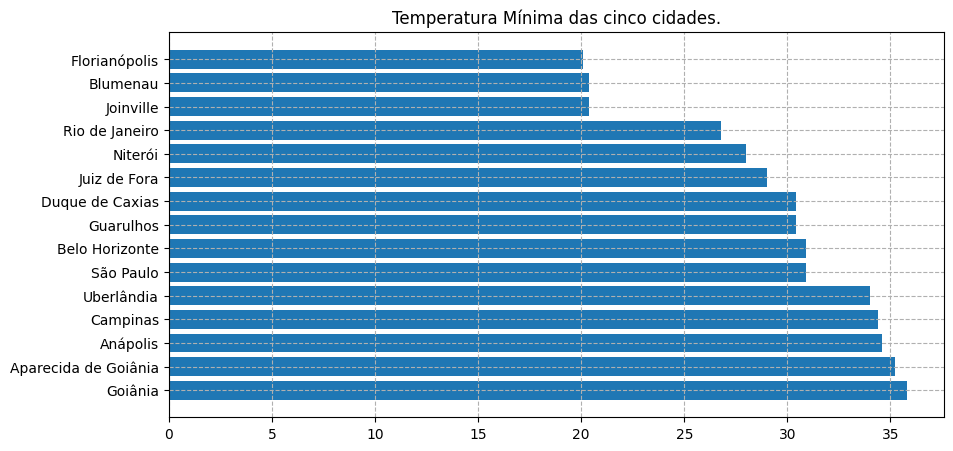

In [98]:
plt.figure(figsize= (10, 5))

plt.barh(cidades, temperaturas)
plt.title('Temperatura Mínima das cinco cidades.')

plt.grid(True, linestyle= '--')

In [22]:
if __name__ == '__main__':
    main()

KeyboardInterrupt: 